In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
img_nadia = cv2.imread('DATA/Nadia_Murad.jpg', 0)
img_denis = cv2.imread('DATA/Denis_Mukwege.jpg', 0)
img_solvay = cv2.imread('DATA/solvay_conference.jpg', 0)

# Face Cascade

In [3]:
face_cascade = cv2.CascadeClassifier("DATA/haarcascades/haarcascade_frontalface_default.xml")

In [4]:
def detect_face(img):
    face_img = img.copy()
    
    face_rect = face_cascade.detectMultiScale(face_img)
    
    for (x,y,w,h) in face_rect:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255,255,255), 10)
    
    return face_img

In [5]:
# dst = detect_face(img_denis)
# plt.imshow(dst, cmap='gray')

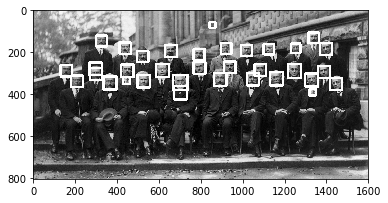

In [6]:
dst = detect_face(img_solvay)
plt.imshow(dst, cmap='gray')

In [7]:
def adjusted_detect_face(img):
    face_img = img.copy()
    
    # scaleFactor - specifying how much the image size is reduced at each image scale.
    # minNeighbors - specifying how many neighbors each candidate rectangle should have to retain it.
    face_rect = face_cascade.detectMultiScale(face_img, scaleFactor=1.2, minNeighbors=5)
    
    for (x,y,w,h) in face_rect:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255,255,255), 10)
    
    return face_img

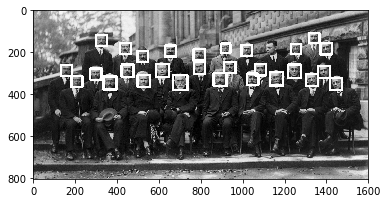

In [8]:
dst = adjusted_detect_face(img_solvay)
plt.imshow(dst, cmap='gray')

# Eye Cascade

In [9]:
eye_cascade = cv2.CascadeClassifier("DATA/haarcascades/haarcascade_eye.xml")

In [28]:
def detect_eyes(img):
    face_img = img.copy()
    
    eye_rect = eye_cascade.detectMultiScale(face_img, scaleFactor=1.2, minNeighbors=5)
    
    for (x,y,w,h) in eye_rect:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (0,255,255), 5)
    
    return face_img

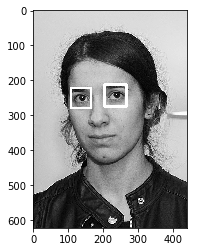

In [24]:
dst = detect_eyes(img_nadia)
plt.imshow(dst, cmap='gray')

# On video

In [21]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read(0)
    
    frame = detect_face(frame)
    
    cv2.imshow('Live Face Detection', frame)
    
    k = cv2.waitKey(1)
    if k == 27:
        break
        
cap.release()
cv2.destroyAllWindows()

In [29]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read(0)
    
    frame = detect_eyes(frame)
    
    cv2.imshow('Live Eye Detection', frame)
    
    k = cv2.waitKey(1)
    if k == 27:
        break
        
cap.release()
cv2.destroyAllWindows()